In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c7adac9d7cbbf0aa6850693ef484bc04b0506116d629d0e6e05bfadf5be8e7b6
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
import shap
import xgboost as xgb
import lime
import lime.lime_tabular

In [ ]:
# Load dataset
dataset = pd.read_csv("/content/adr6.csv")

<ipython-input-67-774671973084>:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("/content/adr6.csv")


In [ ]:
dataset.head()

,client,addrnumber,persnumber,date_from,consnumber,flgdefault,flg_nouse,home_flag,smtp_addr,smtp_srch,dft_receiv,r3_user,encode,tnef,valid_from,valid_to,operation_flag,is_deleted,recordstamp
0,800,8322,733621.0,0001-01-01,1,X,NaN,X,unicorn@cft.tips,UNICORN@CFT.TIPS,NaN,NaN,NaN,NaN,NaN,NaN,I,False,2021-06-19 15:21:01.485512+00:00
1,800,8217,234306.0,0001-01-01,1,X,NaN,X,xeefaxyxa5484@vodafone.de,XEEFAXYXA5484@VODAFO,NaN,NaN,NaN,NaN,NaN,NaN,I,False,2021-03-31 02:34:06.142208+00:00
2,800,8217,234362.0,0001-01-01,1,X,NaN,X,renegesapl45@2golfclubs.com,RENEGESAPL45@2GOLFCL,NaN,NaN,NaN,NaN,NaN,NaN,I,False,2021-03-31 02:34:06.142208+00:00
3,800,8217,234392.0,0001-01-01,1,X,NaN,X,bowerywm@royalston.com,BOWERYWM@ROYALSTON.C,NaN,NaN,NaN,NaN,NaN,NaN,I,False,2021-03-31 02:34:06.142208+00:00
4,800,8217,234774.0,0001-01-01,1,X,NaN,X,uwekeyc9025@comcast.net,UWEKEYC9025@COMCAST.,NaN,NaN,NaN,NaN,NaN,NaN,I,False,2021-03-31 02:34:06.142208+00:00


In [ ]:
# === Data Cleaning ===
print("\n=== Data Cleaning ===")
print("Initial shape:", dataset.shape)


=== Data Cleaning ===
Initial shape: (325510, 19)


In [ ]:
# Check for missing values
missing_values = dataset.isnull().sum()
print("Missing values:\n", missing_values)

Missing values:
 client                 0
addrnumber             0
persnumber         21188
date_from              0
consnumber             0
flgdefault           516
flg_nouse         325426
home_flag            549
smtp_addr           4332
smtp_srch           4332
dft_receiv        325510
r3_user           325510
encode            325510
tnef              325510
valid_from        319903
valid_to          325430
operation_flag         0
is_deleted             0
recordstamp            0
dtype: int64


In [ ]:
# Handle missing values
dataset.fillna("missing", inplace=True)

<ipython-input-71-d43fc6782938>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dataset.fillna("missing", inplace=True)


In [ ]:
# Convert 'recordstamp' to datetime
dataset['recordstamp'] = pd.to_datetime(dataset['recordstamp'], errors='coerce')

# Create time-based features
dataset['hour'] = dataset['recordstamp'].dt.hour
dataset['day_of_week'] = dataset['recordstamp'].dt.dayofweek

dataset['email_domain'] = dataset['smtp_addr'].astype(str).str.extract(r'@([\w\.-]+)').fillna('unknown')
top_domains = dataset['email_domain'].value_counts().nlargest(10).index
dataset['email_domain'] = dataset['email_domain'].apply(lambda x: x if x in top_domains else 'other')

In [ ]:
# Exploratory Data Analysis (EDA)
print("Dataset Overview:")
print(dataset.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325510 entries, 0 to 325509
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   client          325510 non-null  int64              
 1   addrnumber      325510 non-null  int64              
 2   persnumber      325510 non-null  object             
 3   date_from       325510 non-null  object             
 4   consnumber      325510 non-null  int64              
 5   flgdefault      325510 non-null  object             
 6   flg_nouse       325510 non-null  object             
 7   home_flag       325510 non-null  object             
 8   smtp_addr       325510 non-null  object             
 9   smtp_srch       325510 non-null  object             
 10  dft_receiv      325510 non-null  object             
 11  r3_user         325510 non-null  object             
 12  encode          325510 non-null  object             
 

In [ ]:
# Display dataset summaries
print("\nDataset Summary:")
dataset.describe()


Dataset Summary:


,client,addrnumber,consnumber,hour,day_of_week
count,325510.000000,3.255100e+05,325510.000000,325510.000000,325510.000000
mean,799.988787,1.159427e+07,1.018393,2.007266,1.999994
std,2.636385,3.219198e+08,0.674009,0.122263,0.014239
min,50.000000,1.210000e+02,1.000000,0.000000,0.000000
25%,800.000000,8.217000e+03,1.000000,2.000000,2.000000
50%,800.000000,8.217000e+03,1.000000,2.000000,2.000000
75%,800.000000,8.217000e+03,1.000000,2.000000,2.000000
max,800.000000,9.000002e+09,134.000000,20.000000,5.000000


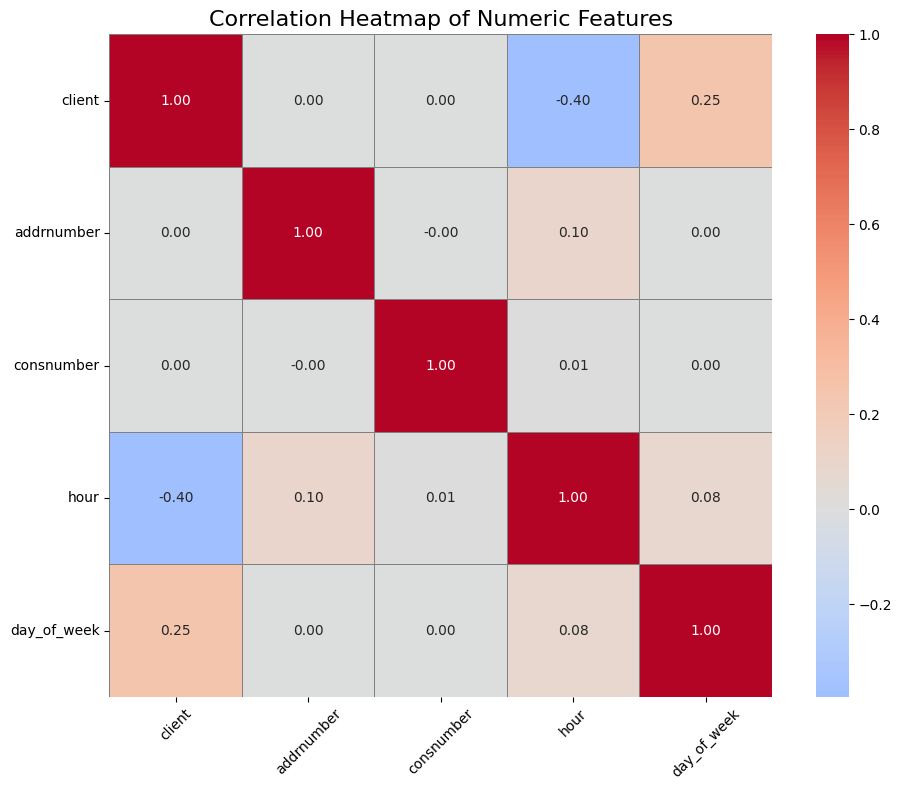

In [ ]:
# Select only numeric columns for correlation
numeric_data = dataset.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numeric_data.corr()

# Set figure size and plot heatmap with coolwarm diverging colormap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='grey', square=True)

plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

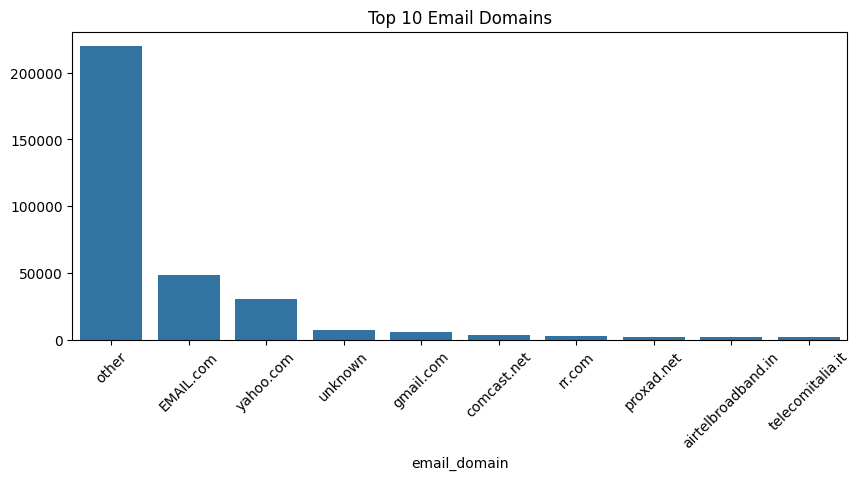

In [ ]:
# === Email domain distribution ===
plt.figure(figsize=(10,4))
top_domains = dataset['email_domain'].value_counts().head(10)
sns.barplot(x=top_domains.index, y=top_domains.values)
plt.title('Top 10 Email Domains')
plt.xticks(rotation=45)
plt.show()

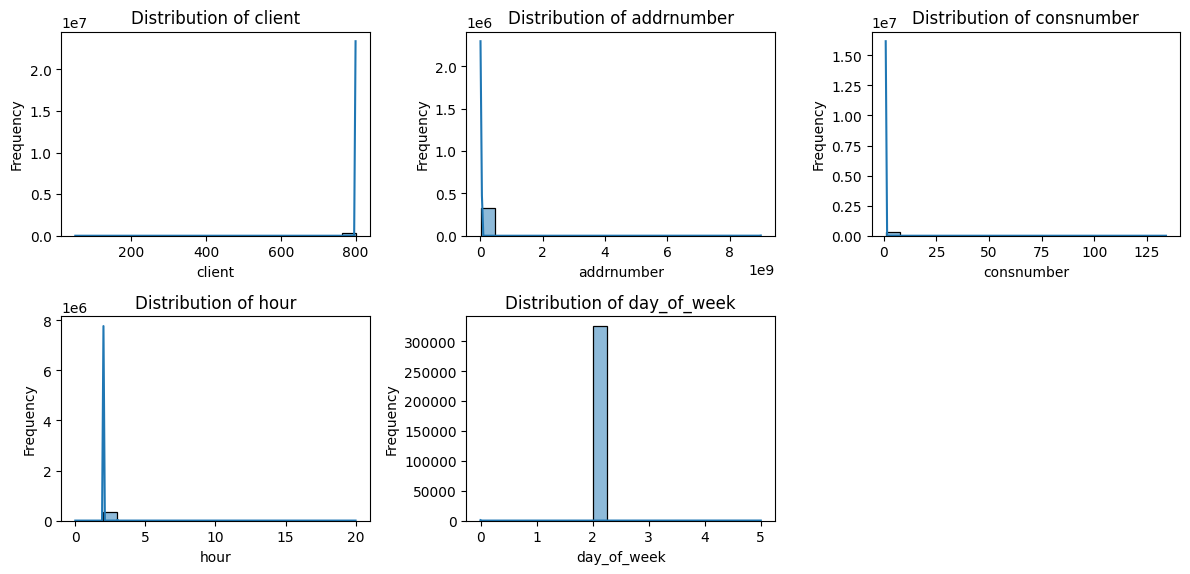

In [ ]:
# Distribution Plot
plt.figure(figsize=(12, 6))
for i, col in enumerate(dataset.select_dtypes(include=[np.number]).columns, 1):
    plt.subplot(2, 3, i)
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

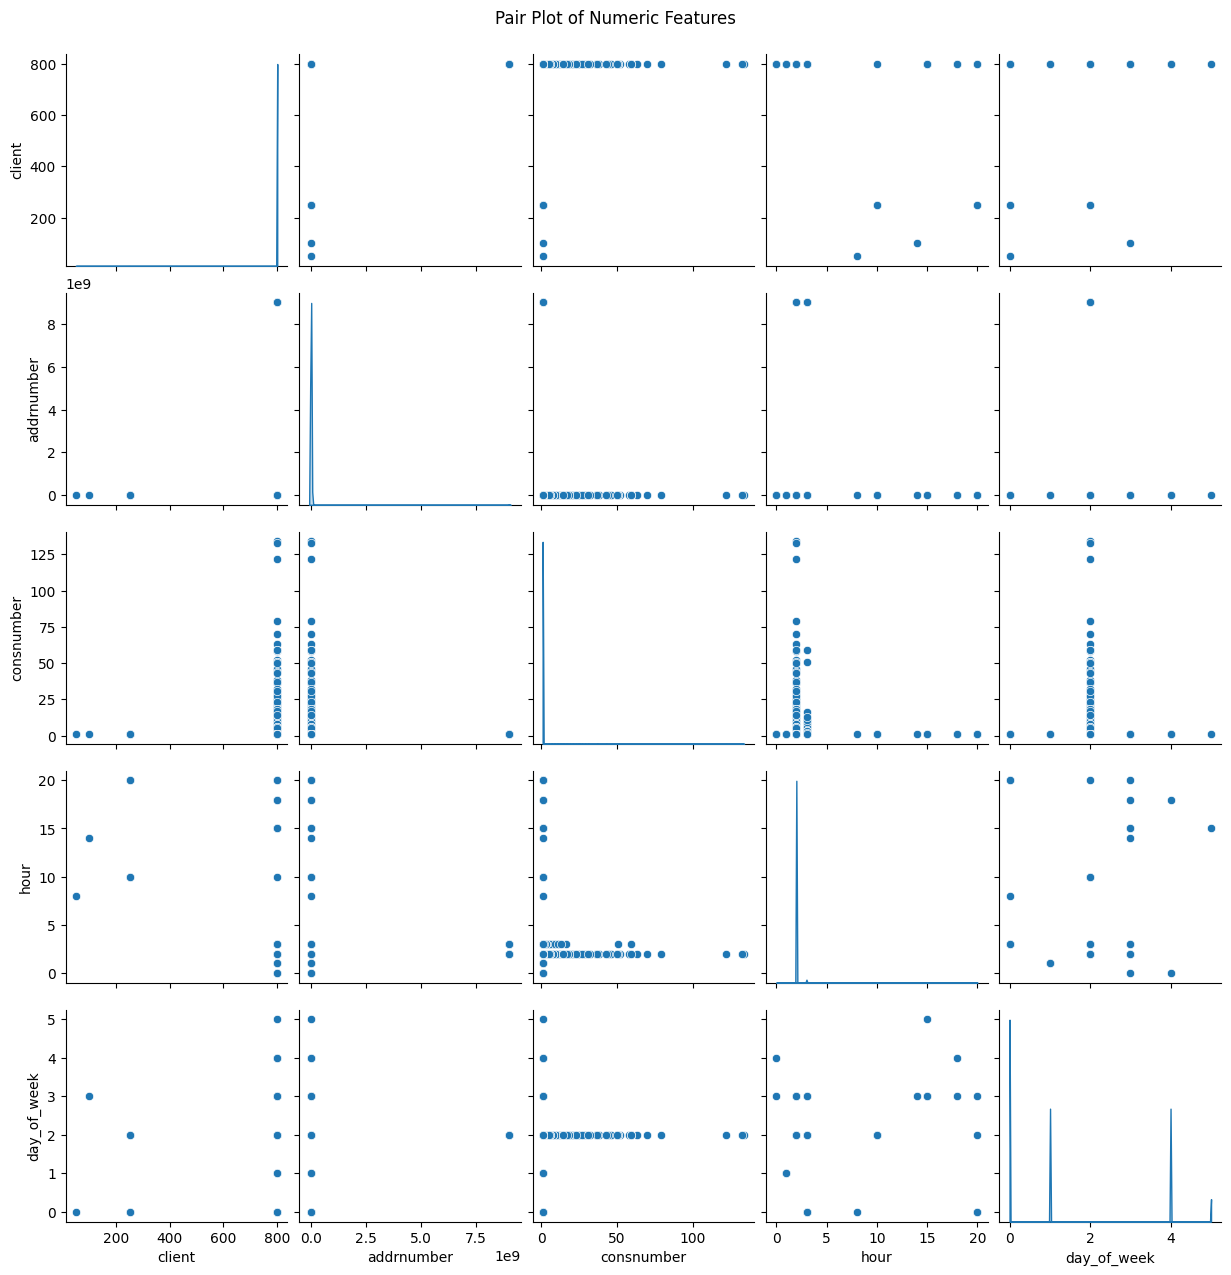

In [ ]:
# Pair Plot
sns.pairplot(dataset.select_dtypes(include=[np.number]), diag_kind='kde')
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

In [ ]:
# Define numeric & categorical features
num_cols = ['addrnumber', 'persnumber', 'consnumber', 'hour', 'day_of_week']
cat_cols = ['client', 'flgdefault', 'home_flag', 'operation_flag', 'is_deleted', 'email_domain']

# Numeric: fill with median
dataset[num_cols] = dataset[num_cols].apply(pd.to_numeric, errors='coerce')  # ensure numeric
dataset[num_cols] = dataset[num_cols].fillna(dataset[num_cols].median())

# Categorical: fill with 'missing'
dataset[cat_cols] = dataset[cat_cols].fillna('missing')

# Define preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# Transform
X = preprocessor.fit_transform(dataset)

In [ ]:
# ---------------------- UNSUPERVISED MODELS ----------------------
# Isolation Forest
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
dataset['if_anomaly'] = iso.fit_predict(X)
dataset['if_anomaly'] = dataset['if_anomaly'].map({1: 0, -1: 1})

# Autoencoder
input_dim = X.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu", activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X, X, epochs=10, batch_size=32, shuffle=True, verbose=0)
X_pred = autoencoder.predict(X)
mse = np.mean(np.power(X - X_pred, 2), axis=1)
threshold = np.percentile(mse, 95)
dataset['ae_anomaly'] = (mse > threshold).astype(int)

10173/10173 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


In [ ]:
# ---------------------- SUPERVISED MODEL (XGBoost) ----------------------
# Simulated compliance violation label
np.random.seed(42)
dataset['label'] = dataset['if_anomaly'] | dataset['ae_anomaly']  # 1 if any model detects anomaly

X_train, X_test, y_train, y_test = train_test_split(X, dataset['label'], test_size=0.2, random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"\nSupervised Evaluation:\nPrecision: {precision:.2f}, Recall: {recall:.2f}, AUROC: {auc:.2f}")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:52:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Supervised Evaluation:
Precision: 0.99, Recall: 0.99, AUROC: 1.00


<ipython-input-82-0c8b58ae1c19>:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:100], plot_type="bar")


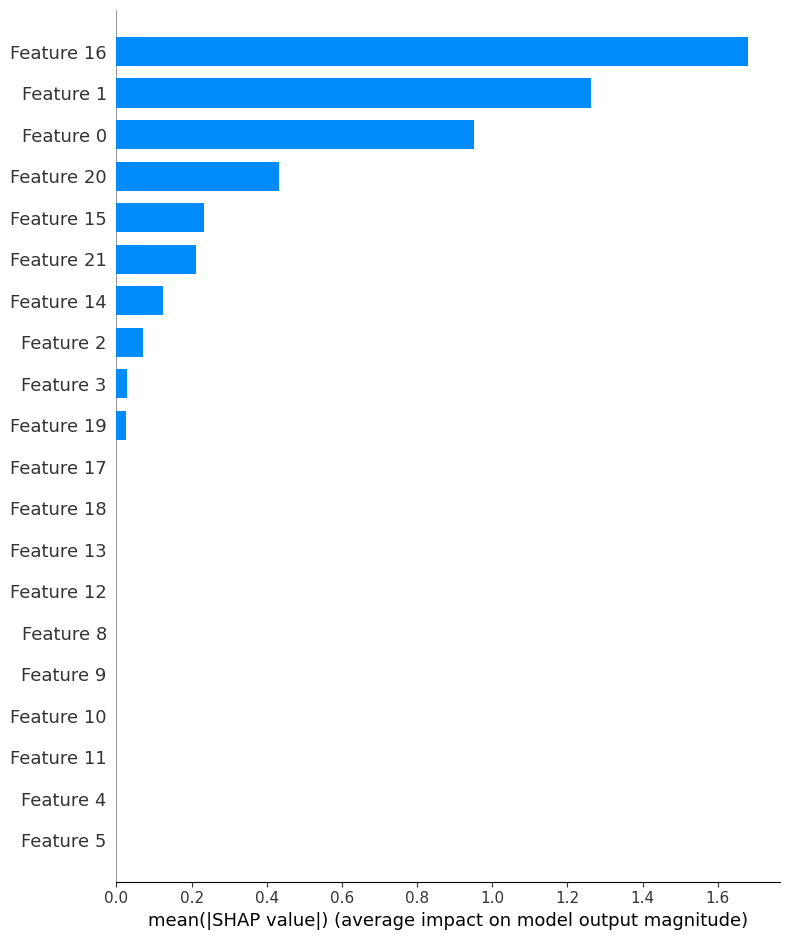

Intercept 1.7361519259895208
Prediction_local [0.20343024]
Right: 5.7274312e-05


In [ ]:
# ---------------------- EXPLAINABILITY ----------------------
# SHAP
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test[:100])
shap.summary_plot(shap_values, X_test[:100], plot_type="bar")

# LIME
lime_explainer = lime.lime_tabular.LimeTabularExplainer(X_train, feature_names=num_cols + list(preprocessor.named_transformers_['cat'].get_feature_names_out()), class_names=['No Violation', 'Violation'], verbose=True)
exp = lime_explainer.explain_instance(X_test[1], xgb_model.predict_proba, num_features=5)
exp.show_in_notebook()

# ---------------------- POLICY ENFORCEMENT SIMULATION ----------------------
# Simulated policy rule (business logic)
dataset['policy_violation'] = ((dataset['hour'].isin([0,1,2,3])) & (dataset['is_deleted'] == 'FALSE')).astype(int)

# Reward function: reduce violations while catching anomalies
dataset['reward'] = (1 - dataset['policy_violation']) * (1 - dataset['label'])  # high reward = low violation + correct prediction

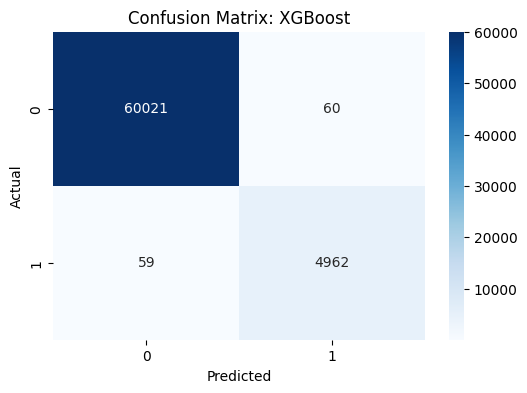

In [ ]:
# ---------------------- VISUALIZATION ----------------------
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

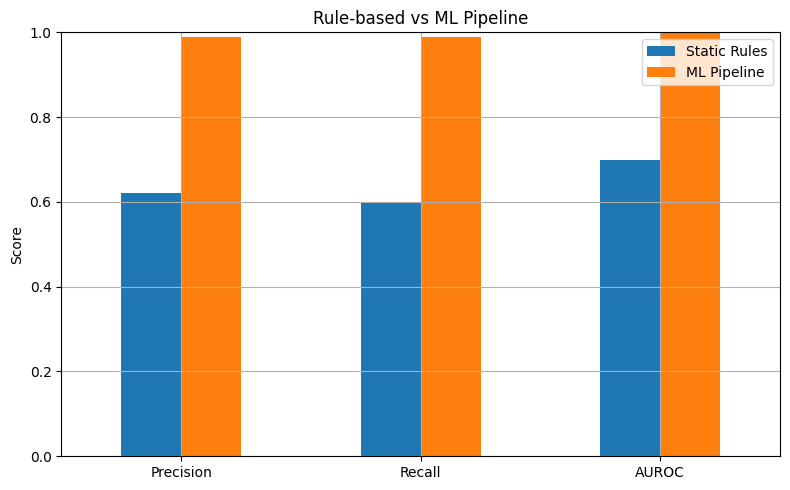

In [ ]:
# Comparison: Rule-based vs ML pipeline
comparison = {
    "Static Rules": [0.62, 0.60, 0.70],
    "ML Pipeline": [precision, recall, auc]
}
comp_df = pd.DataFrame(comparison, index=["Precision", "Recall", "AUROC"])
comp_df.plot(kind='bar', figsize=(8, 5), title="Rule-based vs ML Pipeline", rot=0)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()